# Paul15 — Mouse Myelopoiesis Benchmark

Qualitative and quantitative comparison of manifold-learning methods on the **Paul et al.\ (2015) mouse myeloid progenitor scRNA-seq dataset** \citep{paul2015}, a standard testbed for trajectory inference used in the original PHATE \citep{moon2019phate}, HeatGeo \citep{Huguet2023}, and DTNE \citep{wei2025dtne} papers.

Paul15 captures **multi-lineage hematopoietic differentiation**: a multipotent progenitor (MEP) population branches into erythroid and myeloid lineages, with intermediate cells expressing both lineage markers. The dataset contains ~2700 cells covering MEP, GMP, granulocytes, monocytes, erythroid precursors, megakaryocytes, basophils, and several lineage-intermediate states.

Preprocessing follows DTNE / PHATE / HeatGeo convention for paul15: top 1000 highly-variable genes, log1p transform, then pass the HVG log-expression matrix directly to all methods (no PCA reduction).

## Imports

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parent.parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc

# Method classes
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from umap import UMAP
import phate
from entropath import EntroPath
from heatgeo.embedding import HeatGeo
from dtne import DTNE

from utils.bio_utils import (
    get_bio_methods, run_methods, compute_bio_metrics,
    plot_embedding_row, plot_embedding_grid,
    plot_pseudotime_panels, plot_pseudotime_boxplot,
    save_bio_artifacts, save_metrics_csv,
    geodesic_from_root, correlation_triple,
    BIO_PLOT_ORDER,
)

from entropath import EntroPath

import warnings
warnings.filterwarnings("ignore")
sc.settings.verbosity = 1

## Configuration

`K_NN = 15` matches the cross-dataset bio default. EntroPath defaults (`t_max="auto"`, `mds_solver="smacof"`, `use_landmarks=False`) are appropriate for datasets ≤ 5000 cells and inherited from `bio_utils.get_bio_methods`.

In [2]:
SEED          = 42
K_NN          = 15

# Pseudotime root — first MEP (multipotent progenitor) cell, identified after loading
# Populated below from the data
ROOT_CELL_IDX = None

# Output paths
RESULTS_DIR = PROJECT_ROOT / "results" / "paul15"
FIGURES_DIR = PROJECT_ROOT / "figures" / "paul15"
DATA_DIR    = PROJECT_ROOT / "data" / "paul15"
for d in (RESULTS_DIR, FIGURES_DIR, DATA_DIR):
    d.mkdir(parents=True, exist_ok=True)

print(f"Random seed:  {SEED}")
print(f"k_nn:         {K_NN}")
print(f"Results dir:  {RESULTS_DIR.relative_to(PROJECT_ROOT)}")
print(f"Figures dir:  {FIGURES_DIR.relative_to(PROJECT_ROOT)}")

Random seed:  42
k_nn:         15
Results dir:  results/paul15
Figures dir:  figures/paul15


## Load and preprocess Paul15

Standard scanpy preprocessing matching the DTNE paul15 notebook: top 1000 highly-variable genes (`cell_ranger` flavor) → log1p transform. The HVG log-expression matrix is then used directly as input to all methods, matching the PHATE / DTNE / HeatGeo conventions for this dataset.

Cached to disk so re-runs skip preprocessing.

In [3]:
CACHE_PATH = DATA_DIR / "paul15_preprocessed.h5ad"

if CACHE_PATH.exists():
    print(f"Loading cached preprocessed data from {CACHE_PATH.name}")
    adata = sc.read_h5ad(CACHE_PATH)
else:
    print("Downloading and preprocessing Paul15...")
    adata = sc.datasets.paul15()
    print(f"  Raw: {adata.shape}")

    # Top 1000 highly-variable genes (DTNE / PHATE convention)
    filter_result = sc.pp.filter_genes_dispersion(
        adata.X, flavor="cell_ranger", n_top_genes=1000, log=False,
    )
    adata = adata[:, filter_result.gene_subset]

    # Log transformation
    sc.pp.log1p(adata)

    # Force palette population for paul15_clusters
    sc.pl._tools.scatterplots._get_palette(adata, "paul15_clusters")

    adata.write_h5ad(CACHE_PATH)
    print(f"  Cached to {CACHE_PATH.name}")

print(f"\nShape: {adata.shape}")
print(f"obs keys:  {list(adata.obs.columns)}")
print(f"obsm keys: {list(adata.obsm.keys())}")

Loading cached preprocessed data from paul15_preprocessed.h5ad

Shape: (2730, 1002)
obs keys:  ['paul15_clusters']
obsm keys: []


In [4]:
# Use HVG-1000 log-expression as input (DTNE / PHATE convention for paul15)
X = adata.X.toarray() if hasattr(adata.X, "toarray") else np.asarray(adata.X)
print(f"X shape:      {X.shape}  (HVG-1000 log-expression)")

# Extract labels and palette (use scanpy's bundled paul15 colors)
labels       = adata.obs["paul15_clusters"].values
label_codes  = adata.obs["paul15_clusters"].cat.codes.values
categories   = list(adata.obs["paul15_clusters"].cat.categories)
n_clusters   = len(categories)
zip_types    = dict(zip(categories, adata.uns["paul15_clusters_colors"]))
cell_colors  = [zip_types[l] for l in labels]

# Root cell: use the iroot shipped with sc.datasets.paul15() (= DTNE's root_cells=[840]).
# This is an index into the raw paul15 ordering; our preprocessing subsets genes only,
# so cell order is preserved and the index remains valid.
if "iroot" in adata.uns:
    ROOT_CELL_IDX = int(adata.uns["iroot"])
    print(f"Using shipped iroot: idx={ROOT_CELL_IDX}, label={labels[ROOT_CELL_IDX]}")
    print("  (matches DTNE's root_cells=[840]; note: this cell is an 8Mk in paul15)")
else:
    # If iroot absent (e.g. cell-reordered data), fall back to label-based progenitor root
    mep_mask = (labels == "7MEP")
    ROOT_CELL_IDX = int(np.where(mep_mask)[0][0]) if mep_mask.sum() else 0
    print(f"No iroot; label-based root: idx={ROOT_CELL_IDX}, label={labels[ROOT_CELL_IDX]}")

print(f"\nCell types ({n_clusters}):")
for cat in categories:
    n = int((labels == cat).sum())
    print(f"  {str(cat):>20s}: {n} cells")

X shape:      (2730, 1002)  (HVG-1000 log-expression)
Using shipped iroot: idx=840, label=8Mk
  (matches DTNE's root_cells=[840]; note: this cell is an 8Mk in paul15)

Cell types (19):
                  1Ery: 43 cells
                  2Ery: 329 cells
                  3Ery: 246 cells
                  4Ery: 124 cells
                  5Ery: 180 cells
                  6Ery: 173 cells
                  7MEP: 167 cells
                   8Mk: 68 cells
                  9GMP: 63 cells
                 10GMP: 153 cells
                  11DC: 30 cells
                12Baso: 69 cells
                13Baso: 300 cells
                  14Mo: 373 cells
                  15Mo: 186 cells
                 16Neu: 164 cells
                 17Neu: 22 cells
                 18Eos: 9 cells
               19Lymph: 31 cells


## Run all methods

Seven-method bio comparison set from `bio_utils.get_bio_methods`. Paul15 at n~2700 is small enough that all methods complete in seconds.

In [5]:
#methods = get_bio_methods(SEED, k_nn=K_NN)

methods = {
    "PCA":       PCA(n_components=2),
    "t-SNE":     TSNE(perplexity=30, random_state=SEED),
    "UMAP":      UMAP(random_state=SEED),
    "PHATE":     phate.PHATE(knn=30, n_jobs=-2, random_state=SEED, verbose=False),
    "HeatGeo":   HeatGeo(knn=5),
    "DTNE":      DTNE(k_neighbors=30),
    "EntroPath": EntroPath(k_neighbors=15, kernel="alpha_decay", mds_solver="smacof",
                           landmarks_method="kmeans", random_state=SEED, verbose=False),
}

print(f"Methods: {list(methods.keys())}\n")
embeddings, runtimes = run_methods(methods, X)

Methods: ['PCA', 't-SNE', 'UMAP', 'PHATE', 'HeatGeo', 'DTNE', 'EntroPath']

  PCA                done (   0.0s)
  t-SNE              done (   5.4s)
  UMAP               

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


done (   7.2s)
  PHATE                  SGD-MDS may not have converged: stress changed by -3.9% in final iterations. Consider increasing n_iter or adjusting learning_rate.
done (   3.4s)
  HeatGeo            Using s_gd2 for MDS. None
done (   4.3s)
  DTNE               done (   5.8s)
  EntroPath          done (   7.9s)  (t_power = 21)

=== Done — 7/7 methods succeeded ===


## Quantitative metrics

ARI/NMI from Agglomerative clustering on each embedding, trustworthiness against the HVG log-expression reference, and DTNE-style subsampled DEMaP \citep{wei2025dtne}.

In [6]:
df_paul15 = compute_bio_metrics(
    embeddings, X,
    label_codes=label_codes,
    n_clusters=n_clusters,
    demap_n_subsample=500,
    runtimes=runtimes,
    plot_order=BIO_PLOT_ORDER,
    random_state=SEED,
)

print()
print(df_paul15.round(3).to_string())
print()
print("=== LaTeX ===")
print(df_paul15.round(3).to_latex(escape=False, float_format="%.3f"))

Computing bio metrics:
  DEMaP: n_subsample=500, n_repeats=50, knn=50
  Trustworthiness/Continuity: k=15
  X_input == X_ref (single reference, shape (2730, 1002))

  PCA                DEMaP = 0.875 ± 0.005, T = 0.919, C = 0.925
  t-SNE              DEMaP = 0.912 ± 0.003, T = 0.940, C = 0.957
  UMAP               DEMaP = 0.901 ± 0.004, T = 0.929, C = 0.955
  PHATE              DEMaP = 0.885 ± 0.004, T = 0.933, C = 0.936
  HeatGeo            DEMaP = 0.760 ± 0.013, T = 0.926, C = 0.936
  DTNE               DEMaP = 0.886 ± 0.004, T = 0.926, C = 0.942
  EntroPath          DEMaP = 0.946 ± 0.002, T = 0.920, C = 0.939

           DEMaP (mean)  DEMaP (std)    ARI    NMI  Trustworthiness  Continuity  Runtime (s)
Method                                                                                      
PCA               0.875        0.005  0.193  0.425            0.919       0.925        0.007
t-SNE             0.912        0.003  0.280  0.538            0.940       0.957        5.440
UMAP    

## Plots

### Embedding row — primary figure

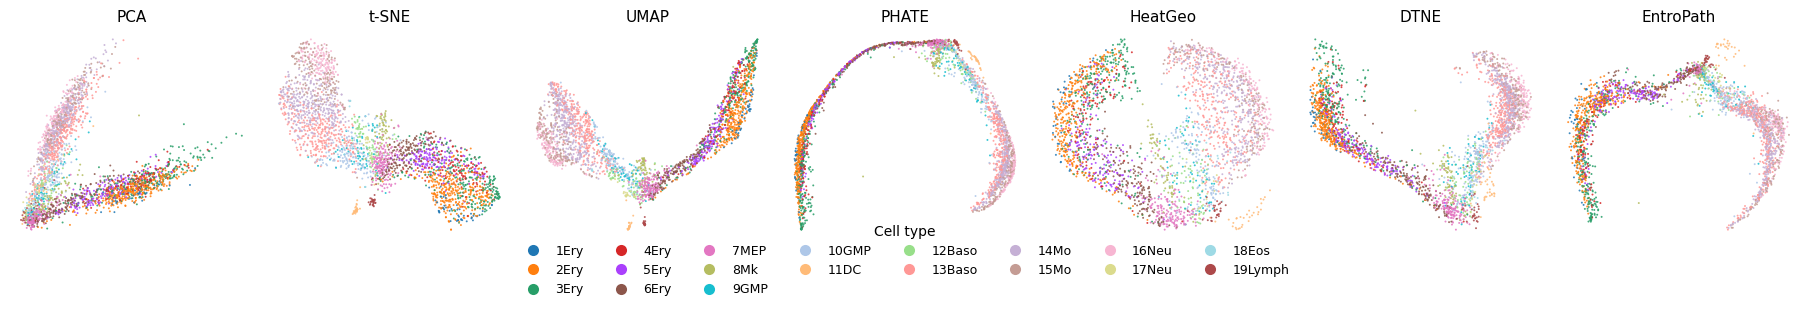

(<Figure size 1820x295 with 7 Axes>,
 array([<Axes: title={'center': 'PCA'}>, <Axes: title={'center': 't-SNE'}>,
        <Axes: title={'center': 'UMAP'}>,
        <Axes: title={'center': 'PHATE'}>,
        <Axes: title={'center': 'HeatGeo'}>,
        <Axes: title={'center': 'DTNE'}>,
        <Axes: title={'center': 'EntroPath'}>], dtype=object))

In [7]:
plot_embedding_row(
    embeddings, BIO_PLOT_ORDER, cell_colors, zip_types,
    runtimes=None,
    save_path=FIGURES_DIR / "paul15_row",
)

### Embedding grid (alternative layout)

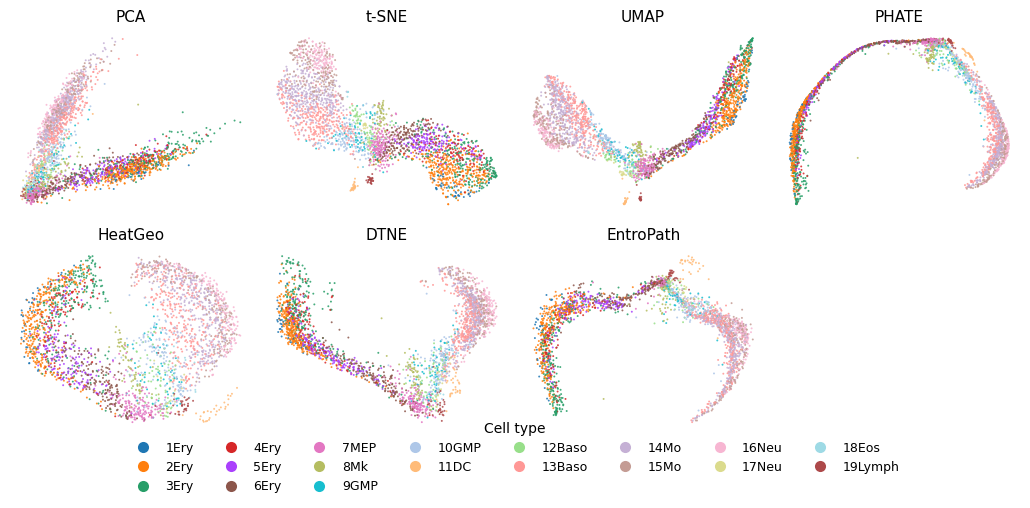

(<Figure size 1040x490 with 8 Axes>,
 array([<Axes: title={'center': 'PCA'}>, <Axes: title={'center': 't-SNE'}>,
        <Axes: title={'center': 'UMAP'}>,
        <Axes: title={'center': 'PHATE'}>,
        <Axes: title={'center': 'HeatGeo'}>,
        <Axes: title={'center': 'DTNE'}>,
        <Axes: title={'center': 'EntroPath'}>, <Axes: >], dtype=object))

In [8]:
plot_embedding_grid(
    embeddings, BIO_PLOT_ORDER, cell_colors, zip_types,
    runtimes=None,
    save_path=FIGURES_DIR / "paul15_grid",
)

## Save artifacts

In [9]:
artifact_path = save_bio_artifacts(
    embeddings, runtimes, labels, label_codes, zip_types,
    X_shape=X.shape,
    config={"seed": SEED, "k_nn": K_NN, "root_cell": ROOT_CELL_IDX},
    results_dir=RESULTS_DIR,
    basename="paul15",
)
metrics_path = save_metrics_csv(df_paul15, RESULTS_DIR, "paul15")

print(f"Embeddings saved to {artifact_path.relative_to(PROJECT_ROOT)}")
print(f"Metrics saved to    {metrics_path.relative_to(PROJECT_ROOT)}")

Embeddings saved to results/paul15/paul15_embeddings.pkl
Metrics saved to    results/paul15/paul15_metrics.csv


## EntroPath downstream analysis (optional)

Pseudotime ordering and pseudotime-based clustering using EntroPath's integrated methods. Root cell is the first MEP cell, identified programmatically above.

Root cell 840: type = 8Mk


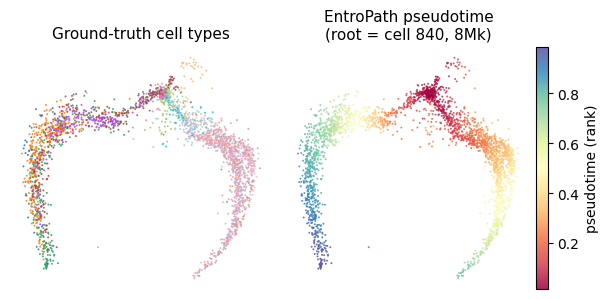


Pseudotime range: [0.014, 0.988]


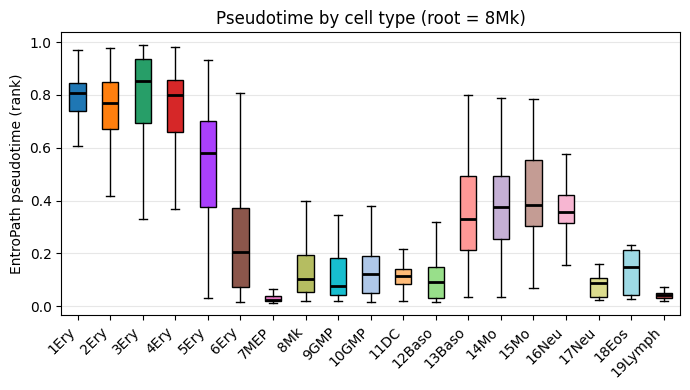

In [10]:
RUN_ENTROPATH_DOWNSTREAM = True

if RUN_ENTROPATH_DOWNSTREAM and "EntroPath" in embeddings:
    pseudotime = plot_pseudotime_panels(
        methods["EntroPath"], "EntroPath",
        embeddings["EntroPath"], ROOT_CELL_IDX,
        labels, cell_colors, zip_types,
        save_path=FIGURES_DIR / "paul15_entropath_pseudotime",
    )
    if pseudotime is not None:
        adata.obs["pseudotime_entropath"] = pseudotime
        print(f"\nPseudotime range: [{pseudotime.min():.3f}, {pseudotime.max():.3f}]")
        plot_pseudotime_boxplot(
            pseudotime, labels,
            adata.obs["paul15_clusters"].cat.categories,
            zip_types,
            method_name="EntroPath",
            root_label=labels[ROOT_CELL_IDX],
            save_path=FIGURES_DIR / "paul15_pseudotime_by_type",
        )
elif RUN_ENTROPATH_DOWNSTREAM:
    print("EntroPath embedding not available — skipping downstream.")
else:
    print("Pseudotime skipped (set RUN_ENTROPATH_DOWNSTREAM = True)")

## DTNE downstream analysis (optional, for cross-method comparison)

Root cell 840: type = 8Mk


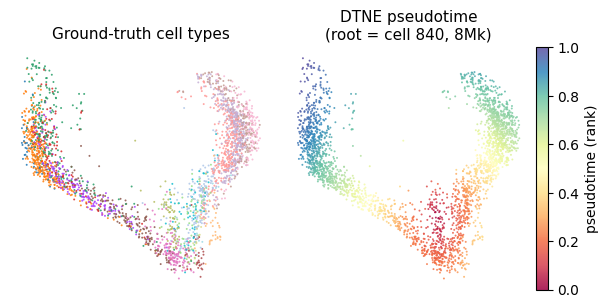


Pseudotime range: [0.000, 1.000]


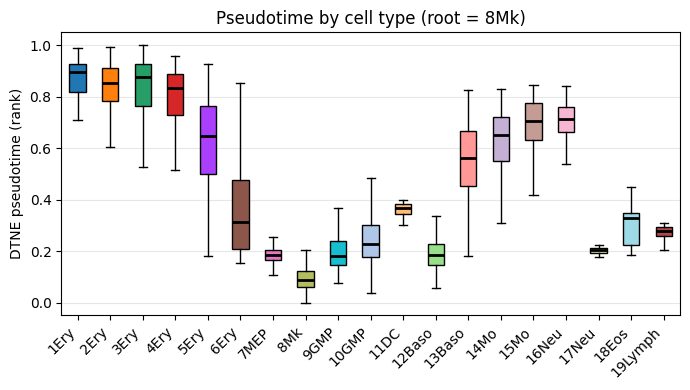

In [11]:
RUN_DTNE_DOWNSTREAM = True

if RUN_DTNE_DOWNSTREAM and "DTNE" in embeddings:
    pseudotime = plot_pseudotime_panels(
        methods["DTNE"], "DTNE",
        embeddings["DTNE"], ROOT_CELL_IDX,
        labels, cell_colors, zip_types,
        order_method="order_cells",
        save_path=FIGURES_DIR / "paul15_dtne_pseudotime",
    )
    if pseudotime is not None:
        adata.obs["pseudotime_dtne"] = pseudotime
        print(f"\nPseudotime range: [{pseudotime.min():.3f}, {pseudotime.max():.3f}]")
        plot_pseudotime_boxplot(
            pseudotime, labels,
            adata.obs["paul15_clusters"].cat.categories,
            zip_types,
            method_name="DTNE",
            root_label=labels[ROOT_CELL_IDX],
            save_path=FIGURES_DIR / "dtne_paul15_pseudotime_by_type",
        )
elif RUN_DTNE_DOWNSTREAM:
    print("DTNE embedding not available — skipping downstream.")
else:
    print("Pseudotime skipped (set RUN_DTNE_DOWNSTREAM = True)")

In [12]:
from scipy.stats import spearmanr

if "pseudotime_entropath" in adata.obs and "pseudotime_dtne" in adata.obs:
    pt_ep = adata.obs["pseudotime_entropath"].values
    pt_dt = adata.obs["pseudotime_dtne"].values
    mask = ~(np.isnan(pt_ep) | np.isnan(pt_dt))
    rho, _ = spearmanr(pt_ep[mask], pt_dt[mask])
    print(f"Pseudotime Spearman (EntroPath vs DTNE): {rho:.3f}")

Pseudotime Spearman (EntroPath vs DTNE): 0.947


In [13]:
ROOT = ROOT_CELL_IDX
geo = geodesic_from_root(X, ROOT, k_neighbors=20)
n_unreachable = int(np.isinf(geo).sum())
if n_unreachable:
    print(f"note: {n_unreachable}/{len(geo)} cells unreachable from root "
          f"at k=20; correlations use reachable cells only\n")

# Each method's pseudotime.
pseudotimes = {}
for name, key in [("EntroPath", "pseudotime_entropath"), ("DTNE", "pseudotime_dtne")]:
    if key in adata.obs:
        pseudotimes[name] = adata.obs[key].values
    else:
        print(f"[skip] {key} not in adata.obs — pseudotime not computed")

print(f"Geodesic-pseudotime correlation "
      f"(high-D input, k_neighbors=20, root cell {ROOT}, label={labels[ROOT]}):")
print(f"{'Method':<12s}  {'Pearson':>8s}  {'Spearman':>8s}  {'Kendall':>8s}")
print("-" * 44)
rows = []
for name, pt in pseudotimes.items():
    p, s, k = correlation_triple(geo, pt)
    print(f"{name:<12s}  {p:>8.3f}  {s:>8.3f}  {k:>8.3f}")
    rows.append({"Method": name, "Pearson": p, "Spearman": s, "Kendall": k})

df_geo = pd.DataFrame(rows).set_index("Method")
geo_path = RESULTS_DIR / "paul15_geodesic_pseudotime_corr.csv"   # paul15, not inherited name
df_geo.to_csv(geo_path)
print(f"\nSaved to {geo_path.relative_to(PROJECT_ROOT)}")
print("\n=== LaTeX ===")
print(df_geo.round(3).to_latex(float_format="%.3f"))

Geodesic-pseudotime correlation (high-D input, k_neighbors=20, root cell 840, label=8Mk):
Method         Pearson  Spearman   Kendall
--------------------------------------------
EntroPath        0.930     0.951     0.825
DTNE             0.927     0.963     0.827

Saved to results/paul15/paul15_geodesic_pseudotime_corr.csv

=== LaTeX ===
\begin{tabular}{lrrr}
\toprule
 & Pearson & Spearman & Kendall \\
Method &  &  &  \\
\midrule
EntroPath & 0.930 & 0.951 & 0.825 \\
DTNE & 0.927 & 0.963 & 0.827 \\
\bottomrule
\end{tabular}



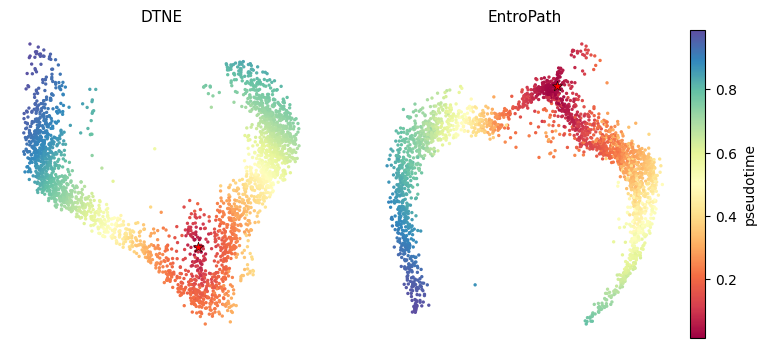

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, method, key in [(axes[0], "DTNE", "pseudotime_dtne"),
                        (axes[1], "EntroPath", "pseudotime_entropath")]:
    emb = embeddings[method]
    pt = adata.obs[key].values
    sca = ax.scatter(emb[:, 0], emb[:, 1], c=pt, s=2, cmap="Spectral", rasterized=True)
    # mark the root cell
    ax.scatter(*emb[ROOT_CELL_IDX], s=60, c="red", marker="*", edgecolor="k", linewidths=0.4)
    ax.set_title(f"{method}", fontsize=11)
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values(): sp.set_visible(False)
fig.colorbar(sca, ax=axes, fraction=0.025, pad=0.02, label="pseudotime")
plt.savefig(FIGURES_DIR / "paul15_pseudotime_comparison.pdf", dpi=400, bbox_inches="tight")
plt.show()

In [15]:
n_disconnected = np.sum(~np.isfinite(geo))
if n_disconnected > 0:
    print(f"WARNING: {n_disconnected} cells unreachable from root. "
          f"Increase k_neighbors.")